# INCT: Instant Neural Compression for Tomography

This notebook demonstrates the INCT library, which implements Instant Neural Graphics Primitives (NGP)
for compressing tomographic projection data.

**Key concepts:**
- Multi-resolution hash encoding (from Instant NGP paper)
- Small MLP decoder
- Learns a function: coordinates → intensity values
- Achieves high compression ratios while maintaining quality

## 1. Setup and Imports

In [1]:
try:
    import torch_dct
except ImportError:
    !pip install torch_dct
    !pip install zarr
    !pip install huffman
    !apt-get update && apt-get install -y ffmpeg

In [2]:
# Add project root to path
import sys
from pathlib import Path

project_root = Path.cwd().parent
sys.path.insert(0, str(project_root))
print(f"Added {project_root} to Python path")

Added /myhome/sdate to Python path


In [3]:
import numpy as np
import matplotlib.pyplot as plt
import torch
from torch.utils.data import DataLoader
from tqdm.auto import tqdm
import time

# Import INCT library
from inct import (
    InstantNGPModel,
    MultiResolutionHashEncoding,
    BatchVoxelDataset,
    ProjectionVolumeDataset,
    ProjectionSliceDataset,
    ChunkedProjectionDataset,
    Trainer,
    TrainingConfig,
    BatchSliceDataset,
    SliceDataset,
    psnr,
    mse,
)
from inct.utils import get_model_size_bytes, compute_compression_ratio

# Import TomographyFolderProcessor for loading data
from sdate.datasets.projection_triplet_dataset import (
    TomographyFolderProcessor,
    load_tomography_params,
)

# Setup matplotlib
plt.rcParams['figure.figsize'] = (14, 10)
plt.rcParams['image.cmap'] = 'gray'

# Device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
print("✅ Libraries imported successfully!")

/opt/conda/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Install with: pip install pillow-heif
Using device: cuda
✅ Libraries imported successfully!


## 3. Load Tomographic Data

We'll load a small subset of projections to test the compression.

In [4]:
# Configuration
DATA_PATH = Path('/myhome/data/sdate/shared/compression_paper/file_1_extracted')
NUM_PROJECTIONS = 50  # Start small for testing
TARGET_SIZE = 1024    # Resize to 256x256 for faster training

# Check if path exists
if DATA_PATH.exists():
    print(f"✅ Data path exists: {DATA_PATH}")
    
    # Load parameters
    tomo_params = load_tomography_params(DATA_PATH)
    print(f"\n📊 Tomography parameters:")
    for k, v in tomo_params.items():
        print(f"   {k}: {v}")
else:
    print(f"❌ Data path not found: {DATA_PATH}")
    print("   Please update DATA_PATH to point to your data folder.")

✅ Data path exists: /myhome/data/sdate/shared/compression_paper/file_1_extracted
✅ Found parameters in JC_62d.log: {'num_darks': 10, 'num_flats': 100, 'num_projections': 1501}

📊 Tomography parameters:
   num_darks: 10
   num_flats: 100
   num_projections: 1501


#### Create dataset

In [5]:
# Create dataset
# Choose the dataset type:
#   'voxel'   - ProjectionVolumeDataset: random voxels uniformly, requires cache_volume=True
#   'slice'   - ProjectionSliceDataset: entire projections at random, supports lazy loading
#   'chunked' - ChunkedProjectionDataset: reads full Zarr chunks, best I/O performance
DATASET_TYPE = 'slice'   # 'voxel' | 'slice' | 'chunked'

ZARR_PATH = DATA_PATH.parent / f"{DATA_PATH.name}_chunked.zarr"  # Zarr store location
cache_volume = True  


if DATA_PATH.exists():

    if DATASET_TYPE == 'slice':
        # Slice-based dataset: samples entire projections at random
        dataset = ProjectionSliceDataset(
            folder_path=DATA_PATH,
            num_projections=NUM_PROJECTIONS,
            # target_size=TARGET_SIZE,
            slices_per_batch=3,       # Number of full slices (projections) per batch
            batch_size=20*65536,      # Subsample down to ~1.3M voxels per batch
            n_batches=200,
            normalize_values=True,
            verbose=True,
            cache_volume=cache_volume,
            slice_dim=2,
            use_attenuation=True,
        )
        print(f"\n📊 Dataset Statistics (Slice-based):")
        print(f"   Volume shape: {dataset.shape}")
        print(f"   Total voxels: {dataset.n_voxels:,}")
        print(f"   Slices per batch: {dataset.slices_per_batch}")
        print(f"   Voxels per batch: {dataset.get_batch_size():,}")

    elif DATASET_TYPE == 'chunked':
        chunk_size = 32
        # Chunked Zarr dataset: samples random chunks and returns ALL voxels in them.
        # One Zarr I/O call per chunk — maximum read performance.
        # First run creates the Zarr store; subsequent runs reuse it automatically.
        dataset = ChunkedProjectionDataset(
            folder_path=DATA_PATH,
            zarr_path=ZARR_PATH,
            num_projections=NUM_PROJECTIONS,
            # target_size=TARGET_SIZE,
            chunks_per_batch=200,       # Number of full 8³ chunks read per batch
            n_batches=200,
            normalize_values=True,
            verbose=True,
            cache_volume=cache_volume,
            return_chunk_shape=False,
            chunk_size=chunk_size,
        )
        stats = dataset.get_statistics()
        print(f"\n📊 Dataset Statistics (Chunked Zarr):")
        print(f"   Volume shape:    {dataset.shape}")
        print(f"   Chunk shape:     {dataset.chunk_shape}")
        print(f"   Total voxels:    {dataset.n_voxels:,}")
        print(f"   Chunks/batch:    {dataset.chunks_per_batch}")
        print(f"   ~Voxels/batch:   {dataset.batch_size:,}")
        print(f"   Zarr store:      {ZARR_PATH}")
        print(f"   P1 / P99:        [{stats['percentile_1']:.4f}, {stats['percentile_99']:.4f}]")

    else:  # 'voxel'
        # Voxel-based dataset: random voxels uniformly from cached volume
        dataset = ProjectionVolumeDataset(
            folder_path=DATA_PATH,
            num_projections=NUM_PROJECTIONS,
            # target_size=TARGET_SIZE,
            batch_size=20*65536,      # ~1.3M voxels per batch
            n_batches=200,
            normalize_values=True,
            verbose=True,
            cache_volume=cache_volume,
            use_attenuation=True,
        )
        print(f"\n📊 Dataset Statistics (Voxel-based):")
        print(f"   Volume shape: {dataset.shape}")
        print(f"   Total voxels: {dataset.n_voxels:,}")
        print(f"   Batch size: {dataset.batch_size:,}")

    print(f"   Batches per epoch: {len(dataset)}")
    print(f"   Value range: [{dataset.value_min:.4f}, {dataset.value_max:.4f}]")

✅ Found parameters in JC_62d.log: {'num_darks': 10, 'num_flats': 100, 'num_projections': 1501}
📂 Loaded folder: file_1_extracted
   Total TIFF files: 1711
   Darks: 10, Flats: 100, Projections: 1501
   Image dimensions: 2560 x 2160
   Use attenuation: True
✅ Loaded cached attenuation data from .tomography_cache_atten.npz
   Range: [-0.1997, 1.7837]
ProjectionSliceDataset:
  Volume shape: (2160, 2560, 50)
  Slice dimension: 2
  Slices per batch: 3
  Voxels per slice (dim=2): 5,529,600
Loading 50 projections...
  Loaded 50/50
Volume shape: (2160, 2560, 50)
Total voxels: 276,480,000
Value range: [-0.1077, 1.5697]

📊 Dataset Statistics (Slice-based):
   Volume shape: (2160, 2560, 50)
   Total voxels: 276,480,000
   Slices per batch: 3
   Voxels per batch: 1,310,720
   Batches per epoch: 200
   Value range: [-0.1077, 1.5697]


/tmp/ipykernel_7522/1137230932.py:18: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


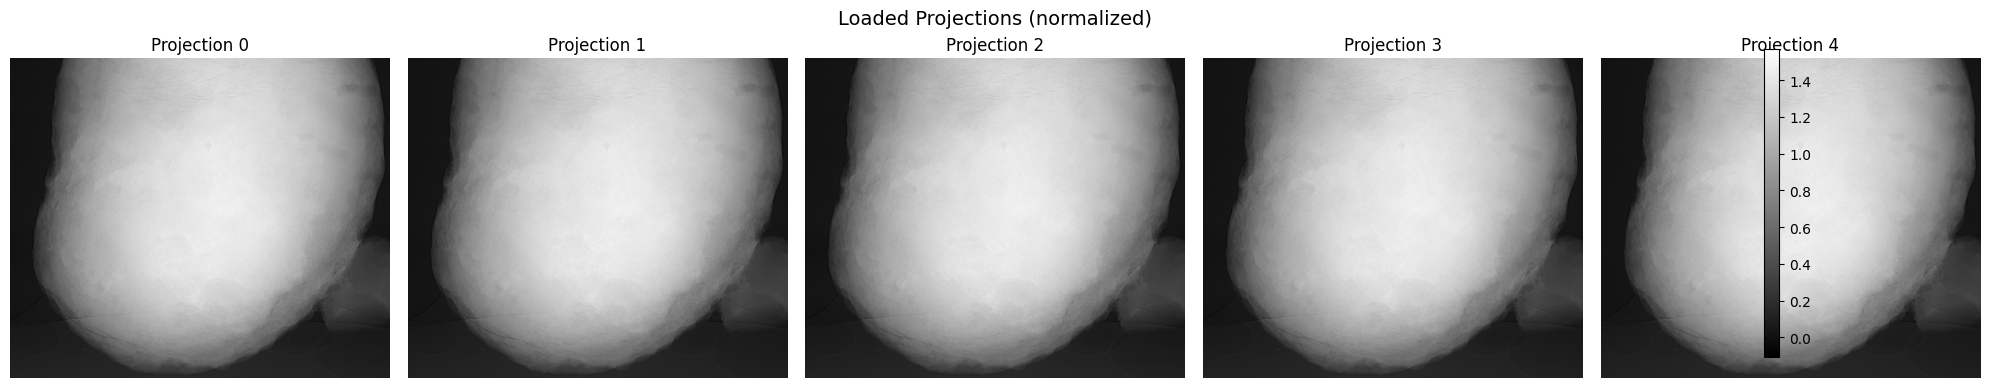

In [6]:
# Visualize the loaded projections
if DATA_PATH.exists() and cache_volume:
    # original = volume = dataset.original_volume
    original = volume = dataset.get_full_volume()
    
    fig, axes = plt.subplots(1, min(NUM_PROJECTIONS, 5), figsize=(4 * min(NUM_PROJECTIONS, 5), 4))
    if NUM_PROJECTIONS == 1:
        axes = [axes]
    
    for i, ax in enumerate(axes):
        proj = volume[:, :, i]
        im = ax.imshow(proj.numpy(), vmin=volume.min(), vmax=volume.max())
        ax.set_title(f'Projection {i}')
        ax.axis('off')
    
    plt.colorbar(im, ax=axes, fraction=0.02)
    plt.suptitle(f'Loaded Projections (normalized)', fontsize=14)
    plt.tight_layout()
    plt.show()

### 3 HEVC compression

In [7]:
from sdate.stream_hvec.stream_gray10 import HevcGray10Streamer, EncoderParams
import tempfile
import os

n_demo_frames = 50

demo_frames = volume.permute(2, 0, 1).clone()
demo_frames -= demo_frames.min()
demo_frames /= demo_frames.max()

# Create a temporary directory for HVEC output
hvec_temp_dir = Path(tempfile.mkdtemp())
hvec_output = hvec_temp_dir / "hvec_compressed_proj.mov"

# Convert frames to torch tensors if needed
demo_frames_torch = torch.stack([torch.tensor(f, dtype=torch.float32) for f in demo_frames])

# demo_frames_torch = demo_frames_torch_all[1:] - demo_frames_torch_all[:-1]
# demo_frames_torch -= demo_frames_torch.min()
# demo_frames_torch /= demo_frames_torch.max()
quality = 80
print(f"🎥 HVEC Compression with quality={quality}...")
print(f"   Input: {len(demo_frames_torch)} frames, shape {demo_frames_torch[0].shape}")

# Create HVEC streamer with quality 90 (similar to our custom compressor)
# Force software encoding since hardware encoder is not available on Linux

params = EncoderParams(
    fps=24,
    cq_hw=quality,  # Hardware quality (not used in software mode)
    crf_sw=min(51, 51 - int(min(quality, 100) * 51 / 100)),  # Software quality - lower is better (0-51)
    preset_sw="slow",
    force_software=True  # Force software encoding (libx265)
)

streamer = HevcGray10Streamer(
    base_path=hvec_temp_dir,
    segment_prefix="demo",
    params=params
)

# Compress all frames to a single segment
with streamer.start_segment():
    for i, frame in enumerate(demo_frames_torch):
        streamer.append_frame(frame)
        if (i + 1) % 2 == 0:
            print(f"   Encoded frame {i+1}/{len(demo_frames_torch)}")

# Get the output file (first segment)
hvec_file = streamer.segments[0]
hvec_size = hvec_file.stat().st_size

print(f"\n✅ HVEC Compression Complete!")
print(f"   Output file: {hvec_file.name}")
print(f"   File size: {hvec_size:,} bytes")
print(f"   Using: {'Hardware' if streamer._using_hardware else 'Software'} encoder")

/tmp/ipykernel_7522/3562938457.py:16: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  demo_frames_torch = torch.stack([torch.tensor(f, dtype=torch.float32) for f in demo_frames])


🎥 HVEC Compression with quality=80...
   Input: 50 frames, shape torch.Size([2160, 2560])
   Encoded frame 2/50
   Encoded frame 4/50
   Encoded frame 6/50
   Encoded frame 8/50
   Encoded frame 10/50
   Encoded frame 12/50
   Encoded frame 14/50
   Encoded frame 16/50
   Encoded frame 18/50
   Encoded frame 20/50
   Encoded frame 22/50
   Encoded frame 24/50
   Encoded frame 26/50
   Encoded frame 28/50
   Encoded frame 30/50
   Encoded frame 32/50
   Encoded frame 34/50
   Encoded frame 36/50
   Encoded frame 38/50
   Encoded frame 40/50
   Encoded frame 42/50
   Encoded frame 44/50
   Encoded frame 46/50
   Encoded frame 48/50
   Encoded frame 50/50

✅ HVEC Compression Complete!
   Output file: demo_0000.mov
   File size: 47,201,224 bytes
   Using: Software encoder


In [8]:
# Calculate compression ratios for comparison
original_size_per_frame = demo_frames[0].nbytes / 2 # Original is 16-bit, but we normalized to float32 for HVEC, so divide by 2 to get original byte size
total_original_size = original_size_per_frame * len(demo_frames)
# HVEC stats
hvec_ratio = total_original_size / hvec_size

print("=" * 80)
print("📊 COMPRESSION COMPARISON")
print("=" * 80)
print(f"\n🔢 Original Data:")
print(f"   Frames: {len(demo_frames)}")
print(f"   Size per frame: {original_size_per_frame:,} bytes ({demo_frames[0].shape})")
print(f"   Total size: {total_original_size:,} bytes ({total_original_size / 1e6:.2f} MB)")
print(f"\n🎥 HVEC (H.265) Compression:")
print(f"   Compressed size: {hvec_size:,} bytes ({hvec_size / 1e6:.2f} MB)")
print(f"   Compression ratio: {hvec_ratio:.2f}x")
print(f"   Space savings: {100 * (1 - hvec_size/total_original_size):.1f}%")


📊 COMPRESSION COMPARISON

🔢 Original Data:
   Frames: 50
   Size per frame: 11,059,200.0 bytes (torch.Size([2160, 2560]))
   Total size: 552,960,000.0 bytes (552.96 MB)

🎥 HVEC (H.265) Compression:
   Compressed size: 47,201,224 bytes (47.20 MB)
   Compression ratio: 11.71x
   Space savings: 91.5%


In [10]:
from sdate.video_compression import decode_hevc_grayscale_10bit

hvec_recovered = decode_hevc_grayscale_10bit(hvec_file, device="cpu")

print(f"✅ Decompressed {len(hvec_recovered)} frames from HVEC")
print(f"   Frame shape: {hvec_recovered[0].shape}")

# Compute PSNR for both methods
def compute_psnr(original, reconstructed):
    original = original.numpy()
    reconstructed = reconstructed.numpy()
    mse = np.mean((original - reconstructed) ** 2)
    if mse == 0:
        return float('inf')
    return 10 * np.log10(1.0 / mse)

print(f"\n📈 Quality Comparison (PSNR):")
print(f"{'Frame':>6} {'Custom PSNR':>12} {'HVEC PSNR':>12}")
print("-" * 35)

hvec_psnrs = []

for i in range(min(len(demo_frames), len(hvec_recovered))):
    hvec_psnr = compute_psnr(demo_frames[i], hvec_recovered[i])
    hvec_psnrs.append(hvec_psnr)

print("-" * 35)
print(f"{'Avg':>6} {np.mean(hvec_psnrs):12.2f}")

✅ Decompressed 50 frames from HVEC
   Frame shape: torch.Size([2160, 2560])

📈 Quality Comparison (PSNR):
 Frame  Custom PSNR    HVEC PSNR
-----------------------------------
-----------------------------------
   Avg        48.67


## 4. Create and Train the INCT Model

In [11]:
# Create the InstantNGP model
model = InstantNGPModel(
    n_dims=3,                      # (height, width, projection_idx)
    n_levels=9,                   # 10 resolution levels
    n_features_per_level=2,        # 2 features per level
    base_resolution=16,            # Coarsest: 32x32x32
    max_resolution=1024,            # Finest: 2048x2048x2048
    table_size=2**19,              # 512K entries per level
    hidden_dims=[128, 128],          # Small MLP: 256-256
    output_dim=1,                  # Single channel output
    output_activation='sigmoid',   # Output in [0, 1]
)

print(model.get_model_info())

# Compute compression statistics
model_size = get_model_size_bytes(model)
original_size = dataset.n_voxels * 2  # 16-bit original
compression_ratio = original_size / model_size

print(f"\n📊 Compression Statistics:")
print(f"   Original size: {original_size / 1024:.2f} KB")
print(f"   Model size: {model_size / 1024:.2f} KB")
print(f"   Compression ratio: {compression_ratio:.1f}x")

InstantNGPModel:
  Input dims: 3
  Total parameters: 9,456,641
  Hash table params: 9,437,184 (99.8%)
  MLP params: 19,457 (0.2%)
  Encoding: 9 levels, 2 features/level
  Resolutions: [16, 26, 45, 76, 127, 215, 362, 608, 1023]

📊 Compression Statistics:
   Original size: 540000.00 KB
   Model size: 36941.69 KB
   Compression ratio: 14.6x


In [12]:
# model.load('/myhome/sdate/notebooks/checkpoints_inct_demo/best_model.pt', device)
# model = model.to(device)

In [14]:
# Create dataloader
train_loader = DataLoader(
    dataset,
    batch_size=None,  # Dataset already returns batches
    shuffle=True,
    num_workers=4,#torch.cpu.device_count() if torch.cpu.device_count() > 1 else 0,  # Use multiple workers if available
)

# Training configuration
config = TrainingConfig(
    learning_rate=1e-2,
    num_epochs=5,
    log_interval=20,
    eval_interval=2,
    checkpoint_interval=10,
    checkpoint_dir='checkpoints_inct_demo',
    loss_fn='mse',
    lr_scheduler='cosine',
    lr_warmup_steps=100,
    use_chunked_dct_loss=False,
    # dct_block_size=chunk_size,
    dct_quality=80,
    soft_quantize_temp=10.0,
    rate_weight=0.01,  # Adjust for rate-distortion tradeoff
    distortion_weight=1.0,
)

print("Training configuration:")
print(f"  Learning rate: {config.learning_rate}")
print(f"  Epochs: {config.num_epochs}")
print(f"  LR scheduler: {config.lr_scheduler}")
print(f"  Use chunked DCT loss: {config.use_chunked_dct_loss}")
print(f"  DCT block size: {config.dct_block_size}")
print(f"  DCT quality: {config.dct_quality}")
print(f"  Soft quantize temperature: {config.soft_quantize_temp}")
print(f"  Rate weight: {config.rate_weight}")
print(f"  Distortion weight: {config.distortion_weight}")

Training configuration:
  Learning rate: 0.01
  Epochs: 5
  LR scheduler: cosine
  Use chunked DCT loss: False
  DCT block size: 8
  DCT quality: 80
  Soft quantize temperature: 10.0
  Rate weight: 0.01
  Distortion weight: 1.0


In [15]:
# Create trainer and train
trainer = Trainer(model, config, device=device)

print("🚀 Starting training...")
print("="*60)

start_time = time.time()
history = trainer.train(
    train_dataloader=train_loader,
    val_dataloader=train_loader,
    verbose=True,
)
training_time = time.time() - start_time

print(f"\n✅ Training completed in {training_time:.1f}s")

model.save('/myhome/sdate/notebooks/checkpoints_inct_demo/best_model.pt')

🚀 Starting training...
Starting training for 5 epochs
Device: cuda
InstantNGPModel:
  Input dims: 3
  Total parameters: 9,456,641
  Hash table params: 9,437,184 (99.8%)
  MLP params: 19,457 (0.2%)
  Encoding: 9 levels, 2 features/level
  Resolutions: [16, 26, 45, 76, 127, 215, 362, 608, 1023]


Epoch 2/5: 100%|██████████| 200/200 [01:02<00:00,  3.22it/s, loss=0.000822, lr=9.05e-03]



  Validation - Loss: 0.000347, PSNR: 34.59 dB
  ✅ New best model saved!


Epoch 4/5: 100%|██████████| 200/200 [01:24<00:00,  2.37it/s, loss=0.000134, lr=3.46e-03]



  Validation - Loss: 0.000134, PSNR: 38.73 dB
  ✅ New best model saved!


Epoch 5/5: 100%|██████████| 200/200 [01:26<00:00,  2.32it/s, loss=0.000122, lr=9.64e-04]



Training completed in 419.6s
Total steps: 1000
Best validation loss: 0.000134
Best PSNR: 38.73 dB

✅ Training completed in 419.7s


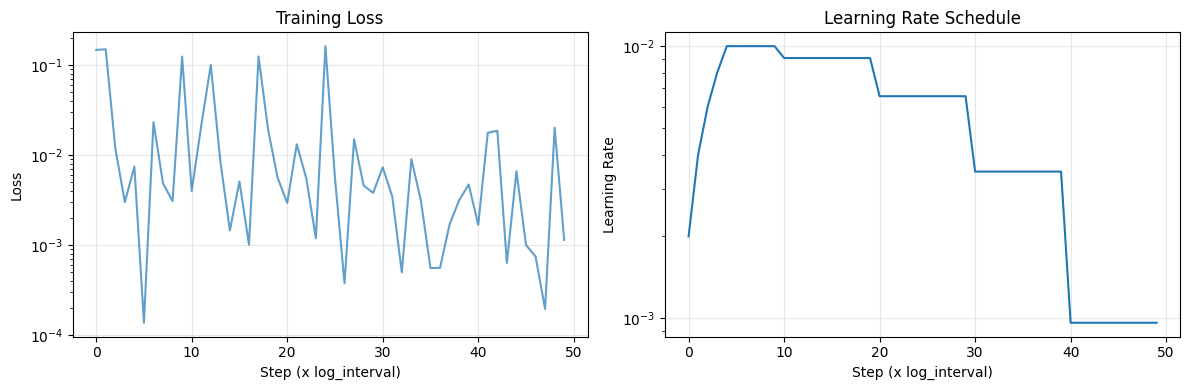

In [ ]:
if 'history' in locals():
    # Plot training history
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    # Loss curve
    axes[0].plot(history['train_losses'], alpha=0.7)
    axes[0].set_xlabel('Step (x log_interval)')
    axes[0].set_ylabel('Loss')
    axes[0].set_title('Training Loss')
    axes[0].set_yscale('log')
    axes[0].grid(True, alpha=0.3)

    # Learning rate
    axes[1].plot(history['learning_rates'])
    axes[1].set_xlabel('Step (x log_interval)')
    axes[1].set_ylabel('Learning Rate')
    axes[1].set_title('Learning Rate Schedule')
    axes[1].set_yscale('log')
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

## 5. Evaluate Reconstruction Quality

In [ ]:
import lovely_tensors as lt
lt.monkey_patch()

In [ ]:
# Reconstruct the full volume
model.eval()
print("Reconstructing volume...")

torch.cuda.empty_cache()
reconstructed = model.predict_volume(
    shape=dataset.shape,
    batch_size=10*65536,
    device=device,
)

# Denormalize
reconstructed = dataset.denormalize_values(reconstructed.cpu())

original = volume

print(f"Original shape: {original}")
print(f"Reconstructed shape: {reconstructed}")

Reconstructing volume...
Original shape: tensor[2160, 2560, 100] n=552960000 (2.1Gb) x∈[8.487e+03, 4.832e+04] μ=2.043e+04 σ=1.009e+04
Reconstructed shape: tensor[2160, 2560, 100] n=552960000 (2.1Gb) x∈[9.027e+03, 4.201e+04] μ=1.995e+04 σ=8.999e+03


In [ ]:
torch.cuda.empty_cache()
# Compute metrics
mse_val = mse(reconstructed, original)
psnr_val = psnr(mse_val, max_val=original.max().item() - original.min().item())

print(f"\n📊 Reconstruction Quality:")
print(f"   MSE: {mse_val:.6f}")
print(f"   PSNR: {psnr_val:.2f} dB")
print(f"   Compression ratio: {compression_ratio:.1f}x")


📊 Reconstruction Quality:
   MSE: 11607301.000000
   PSNR: 21.36 dB
   Compression ratio: 58.3x


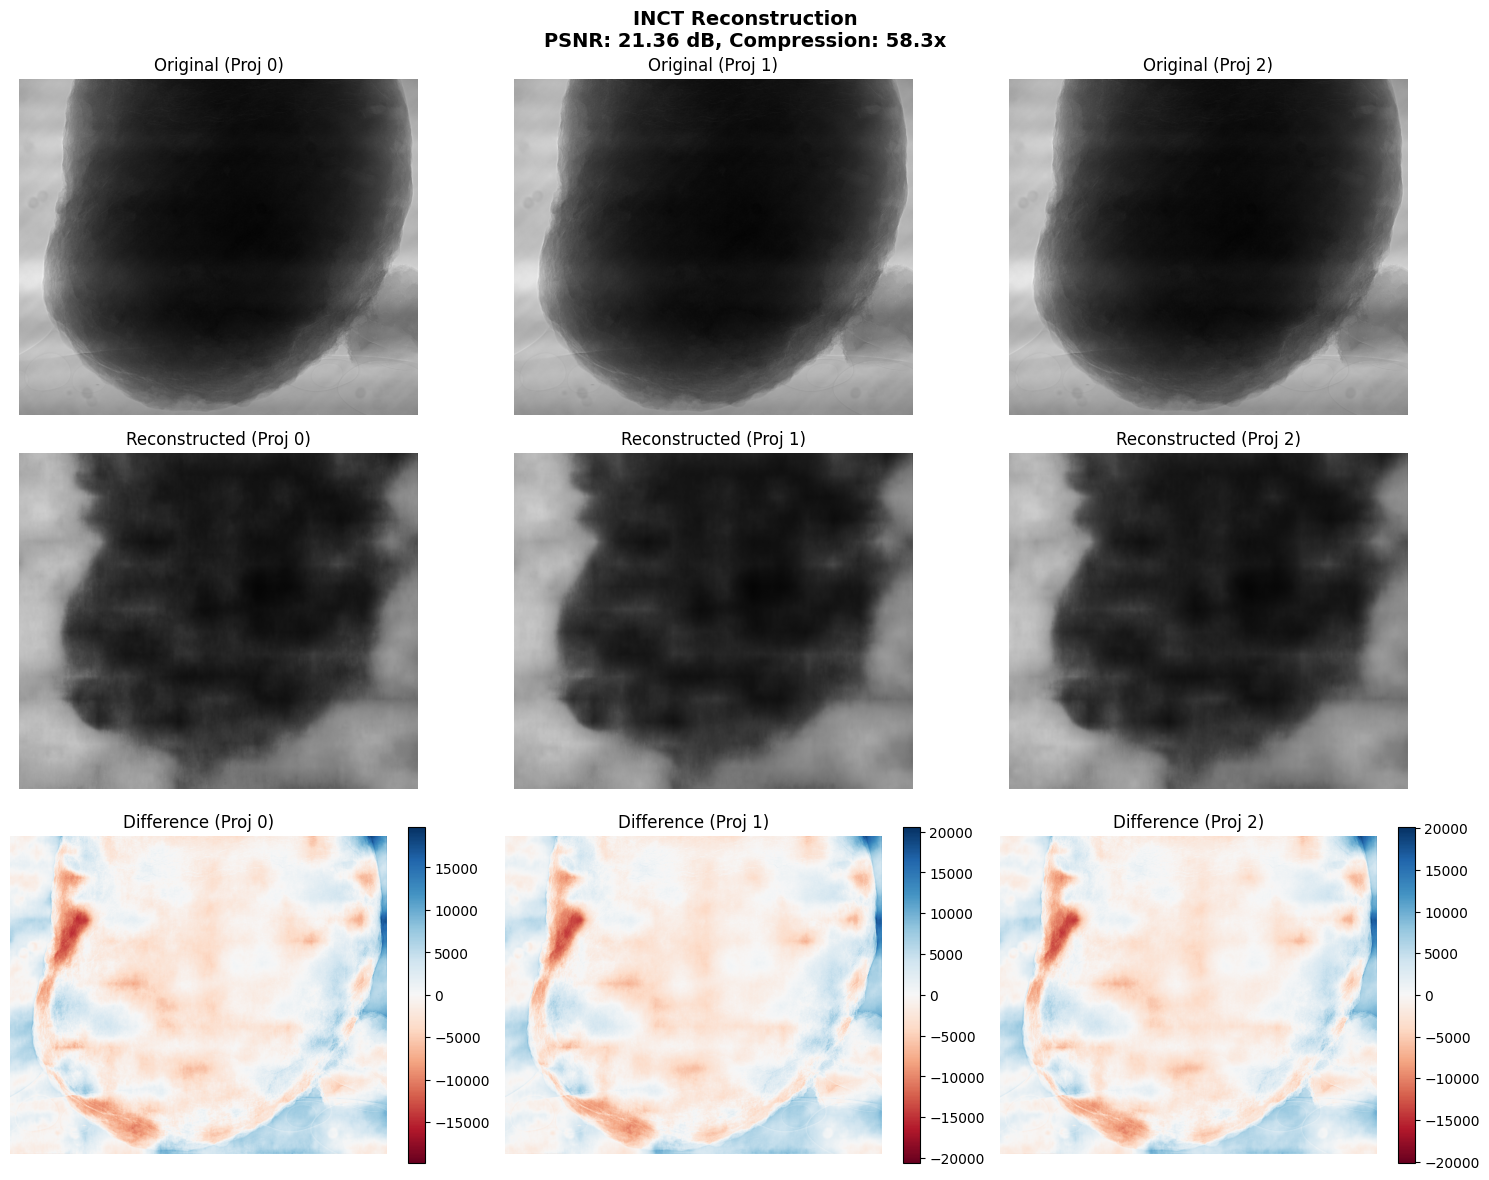

In [ ]:
# Visualize comparison
n_show = min(3, NUM_PROJECTIONS)
fig, axes = plt.subplots(3, n_show, figsize=(5 * n_show, 12))

vmin, vmax = original.min().item(), original.max().item()

for i in range(n_show):
    # Original
    axes[0, i].imshow(original[:, :, i].numpy(), vmin=vmin, vmax=vmax)
    axes[0, i].set_title(f'Original (Proj {i})')
    axes[0, i].axis('off')
    
    # Reconstructed
    axes[1, i].imshow(reconstructed[:, :, i].numpy(), vmin=vmin, vmax=vmax)
    axes[1, i].set_title(f'Reconstructed (Proj {i})')
    axes[1, i].axis('off')
    
    # Difference
    diff = (original[:, :, i] - reconstructed[:, :, i]).numpy()
    vmax_diff = max(abs(diff.min()), abs(diff.max()))
    im = axes[2, i].imshow(diff, cmap='RdBu', vmin=-vmax_diff, vmax=vmax_diff)
    axes[2, i].set_title(f'Difference (Proj {i})')
    axes[2, i].axis('off')
    plt.colorbar(im, ax=axes[2, i], fraction=0.046)

plt.suptitle(f'INCT Reconstruction\nPSNR: {psnr_val:.2f} dB, Compression: {compression_ratio:.1f}x', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

Per-projection metrics:
----------------------------------------


100%|██████████| 100/100 [00:36<00:00,  2.72it/s]


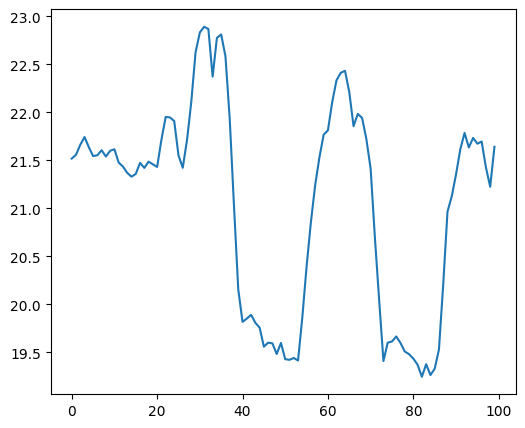

In [ ]:
from tqdm import tqdm
# Per-projection metrics
print("Per-projection metrics:")
print("-" * 40)

mses = []
psnrs = []
for i in tqdm(range(NUM_PROJECTIONS)):
    proj_orig = original[:, :, i]
    proj_recon = reconstructed[:, :, i]
    
    proj_mse = mse(proj_recon, proj_orig)
    proj_psnr = psnr(proj_mse, max_val=proj_orig.max().item() - proj_orig.min().item())
    
    psnrs.append(proj_psnr)
    mses.append(proj_mse)
plt.figure(figsize=(6, 5))
plt.plot(psnrs)

## 8. Hybrid Compression with HEVC

In [ ]:
from sdate.stream_hvec.stream_gray10 import HevcGray10Streamer, EncoderParams
import tempfile
import os

n_frames = original.shape[2]

# First pass: compute min and max for normalization in streaming fashion
print("Computing min/max for normalization (streaming)...")
min_demo = float('inf')
max_demo = float('-inf')

for i in tqdm(range(n_frames), desc="Computing stats"):
    residual_i = original[:, :, i] - reconstructed[:, :, i]
    min_demo = min(min_demo, residual_i.min().item())
    max_demo = max(max_demo, residual_i.max().item())

print(f"Residual value range: [{min_demo:.4f}, {max_demo:.4f}]")
range_demo = max_demo - min_demo

# Create a temporary directory for HVEC output
hvec_temp_dir = Path(tempfile.mkdtemp())
hvec_output = hvec_temp_dir / "hvec_compressed.mov"

quality = 80
print(f"🎥 HVEC Compression with quality={quality}...")
print(f"   Input: {n_frames} frames, shape {original.shape[:2]}")

# Create HVEC streamer with quality 90 (similar to our custom compressor)
# Force software encoding since hardware encoder is not available on Linux

params = EncoderParams(
    fps=24,
    cq_hw=quality,  # Hardware quality (not used in software mode)
    crf_sw=min(51, 51 - int(min(quality, 100) * 51 / 100)),  # Software quality - lower is better (0-51)
    preset_sw="slow",
    force_software=True  # Force software encoding (libx265)
)

streamer = HevcGray10Streamer(
    base_path=hvec_temp_dir,
    segment_prefix="demo",
    params=params
)

# Second pass: stream normalized residuals
with streamer.start_segment():
    for i in tqdm(range(n_frames), desc="Encoding frames"):
        # Compute residual for frame i on-the-fly
        residual_i = original[:, :, i] - reconstructed[:, :, i]
        
        # Normalize to [0, 1] using pre-computed min/max
        frame_normalized = (residual_i - min_demo) / range_demo
        
        # Ensure it's a float32 tensor
        frame_normalized = frame_normalized.float()
        
        streamer.append_frame(frame_normalized)

# Get the output file (first segment)
hvec_file = streamer.segments[0]
hvec_size = hvec_file.stat().st_size

print(f"\n✅ HVEC Compression Complete!")
print(f"   Output file: {hvec_file.name}")
print(f"   File size: {hvec_size:,} bytes")
print(f"   Using: {'Hardware' if streamer._using_hardware else 'Software'} encoder")

In [ ]:
from sdate.video_compression import encode_hevc_grayscale_10bit, decode_hevc_grayscale_10bit
# Calculate compression ratios for comparison
n_frames = original.shape[2]
original_size_per_frame = original[:, :, 0].numel() * original[:, :, 0].element_size()
total_original_size = original_size_per_frame * n_frames
# HVEC stats
hvec_ratio = total_original_size / hvec_size

print("=" * 80)
print("📊 COMPRESSION COMPARISON")
print("=" * 80)
print(f"\n🔢 Original Data:")
print(f"   Frames: {n_frames}")
print(f"   Size per frame: {original_size_per_frame:,} bytes ({original.shape[:2]})")
print(f"   Total size: {total_original_size:,} bytes ({total_original_size / 1e6:.2f} MB)")
print(f"\n🎥 HVEC (H.265) Compression:")
print(f"   Compressed size: {hvec_size:,} bytes ({hvec_size / 1e6:.2f} MB)")
print(f"   Compression ratio: {hvec_ratio:.2f}x")
print(f"   Space savings: {100 * (1 - hvec_size/total_original_size):.1f}%")


hvec_recovered = decode_hevc_grayscale_10bit(hvec_file, device="cpu").permute(1, 2, 0)

print(f"✅ Decompressed {len(hvec_recovered)} frames from HVEC")
print(f"   Frame shape: {hvec_recovered[0].shape}")

# Compute PSNR for both methods
def compute_psnr(original, reconstructed):
    original = original.numpy()
    reconstructed = reconstructed.numpy()
    mse = np.mean((original - reconstructed) ** 2)
    if mse == 0:
        return float('inf')
    return 10 * np.log10(1.0 / mse)

print(f"\n📈 Quality Comparison (PSNR):")
print(f"{'Frame':>6} {'HVEC PSNR':>12}")
print("-" * 25)



hvec_psnrs = []

for i in tqdm(range(min(n_frames, len(hvec_recovered)))):
    # Recompute normalized residual for comparison (streaming fashion)
    residual_i = original[:, :, i] - reconstructed[:, :, i]
    frame_normalized = (residual_i - min_demo) / range_demo
    
    hvec_psnr = compute_psnr(frame_normalized, hvec_recovered[:, :, i])
    hvec_psnrs.append(hvec_psnr)

print("-" * 25)
print(f"{'Avg':>6} {np.mean(hvec_psnrs):12.2f}")

In [ ]:
# Reconstruct hybrid result by denormalizing the HVEC residuals and adding to reconstructed
# hvec_recovered is normalized residuals, need to denormalize: residual = normalized * range + min
hvec_residuals_denorm = hvec_recovered * range_demo + min_demo
hybrid_recon = reconstructed + hvec_residuals_denorm

# compute mse between original and hybrid_recon
mse_hybrid = mse(original, hybrid_recon)
psnr_hybrid = psnr(mse_hybrid, max_val=original.max().item() - original.min().item()).item()
print(f"Hybrid reconstruction PSNR: {psnr_hybrid:.2f} dB")

## 9. Hybrid Compression: INCT + Entropy-Coded Residuals

While INCT provides good compression, we can achieve even better reconstruction quality by encoding the residuals (difference between original and INCT reconstruction) using DCT + quantization + Huffman coding.

**Approach:**
1. Compute residuals: `residual = original - inct_reconstruction`
2. Encode residuals using DCT → Quantization → Huffman (like JPEG)
3. Decode residuals and add back: `final = inct_reconstruction + decoded_residual`
4. Compare quality vs. additional storage cost

In [ ]:
try:
    import torch_dct
    import huffman
except ImportError:
    !pip install torch_dct
    !pip install huffman

In [ ]:
# OPTIMIZED: GPU-batched residual encoding
def encode_residuals_batched(original, reconstructed, encoder, decoder, batch_size=32, block_size=chunk_size):
    """
    Encode residuals for all projections with GPU batching for better performance.
    
    Key optimizations:
    - Batched residual computation on GPU
    - Minimized CPU<->GPU data transfers
    - Pre-allocated arrays
    - Batch processing of projections
    
    Args:
        original: (H, W, N) tensor
        reconstructed: (H, W, N) tensor  
        encoder: ResidualEncoder instance
        decoder: ResidualDecoder instance
        batch_size: Number of projections to process simultaneously on GPU
        block_size: DCT block size (must match encoder)
    
    Returns:
        all_encoded_blobs: List of encoded bytes for each projection
        all_decoded_residuals: List of decoded numpy arrays
        per_proj_metrics: List of dicts with metrics per projection
    """
    import torch
    import time
    
    N = original.shape[2]
    all_encoded_blobs = []
    all_decoded_residuals = []
    per_proj_metrics = []
    
    # Move data to GPU once
    device = encoder.device
    original_gpu = original.to(device).float()
    reconstructed_gpu = reconstructed.to(device).float()
    
    H, W = original.shape[:2]
    pad_h = (block_size - H % block_size) % block_size
    pad_w = (block_size - W % block_size) % block_size
    
    print(f"Processing {N} projections in batches of {batch_size} on {device}")
    start_time = time.time()
    
    # Pre-compute all residuals on GPU in batches
    for batch_start in tqdm(range(0, N, batch_size), desc="Encoding residuals"):
        batch_end = min(batch_start + batch_size, N)
        batch_size_actual = batch_end - batch_start
        
        # Compute residuals for entire batch on GPU
        residuals_batch = (original_gpu[:, :, batch_start:batch_end] - 
                          reconstructed_gpu[:, :, batch_start:batch_end])  # (H, W, batch)
        
        # Pad if needed
        if pad_h > 0 or pad_w > 0:
            residuals_batch_padded = torch.nn.functional.pad(
                residuals_batch, (0, 0, 0, pad_w, 0, pad_h), mode='reflect'
            )
        else:
            residuals_batch_padded = residuals_batch
        
        # Transfer batch to CPU once (more efficient than per-projection)
        residuals_cpu = residuals_batch_padded.cpu().numpy()
        orig_batch_cpu = original_gpu[:, :, batch_start:batch_end].cpu().numpy()
        recon_batch_cpu = reconstructed_gpu[:, :, batch_start:batch_end].cpu().numpy()
        
        # Process each projection in the batch
        for i in range(batch_size_actual):
            proj_idx = batch_start + i
            residual_padded = residuals_cpu[:, :, i]
            
            # Encode (GPU acceleration inside encoder)
            encoded_blob = encoder.encode(residual_padded)
            all_encoded_blobs.append(encoded_blob)
            
            # Decode (GPU acceleration inside decoder)
            decoded_residual = decoder.decode(encoded_blob)
            
            # Unpad
            if pad_h > 0 or pad_w > 0:
                decoded_residual = decoded_residual[:H, :W]
            
            all_decoded_residuals.append(decoded_residual)
            
            # Compute metrics using pre-transferred CPU arrays
            orig_proj = orig_batch_cpu[:H, :W, i]
            recon_proj = recon_batch_cpu[:H, :W, i]
            final_recon = recon_proj + decoded_residual
            
            mse_inct = ((orig_proj - recon_proj) ** 2).mean()
            mse_hybrid = ((orig_proj - final_recon) ** 2).mean()
            
            # Compute PSNR using GLOBAL data range from entire volume
            # (Using per-projection range would make PSNR non-comparable)
            data_range = original_gpu.max().item() - original_gpu.min().item()
            psnr_inct_val = 10 * np.log10(data_range**2 / max(mse_inct, 1e-10))
            psnr_hybrid_val = 10 * np.log10(data_range**2 / max(mse_hybrid, 1e-10))
            
            per_proj_metrics.append({
                'proj_idx': proj_idx,
                'residual_size': len(encoded_blob),
                'mse_inct': float(mse_inct),
                'mse_hybrid': float(mse_hybrid),
                'psnr_inct': psnr_inct_val,
                'psnr_hybrid': psnr_hybrid_val,
            })

    elapsed = time.time() - start_time    
    print(f"✓ Completed in {elapsed:.2f}s ({N/elapsed:.1f} proj/s)")
    return all_encoded_blobs, all_decoded_residuals, per_proj_metrics

In [ ]:
# Import entropy coding utilities
from compress_ct.entropy import ResidualEncoder, ResidualDecoder

# Test with a single projection first
test_proj_idx = 50  # Pick a projection in the middle

# Get original and reconstructed for this projection
orig_proj = original[:, :, test_proj_idx].numpy().astype(np.float32)
recon_proj = reconstructed[:, :, test_proj_idx].numpy().astype(np.float32)

# Compute residual
residual = orig_proj - recon_proj

print(f"Testing residual compression on projection {test_proj_idx}")
print(f"Original shape: {orig_proj.shape}")
print(f"Residual range: [{residual.min():.6f}, {residual.max():.6f}]")
print(f"Residual std: {residual.std():.6f}")

In [ ]:
# Reload the compress_ct.entropy module to get latest changes
import importlib
import compress_ct.entropy

importlib.reload(compress_ct.entropy)
from compress_ct.entropy import ResidualEncoder, ResidualDecoder

print("✅ Reloaded compress_ct.entropy module")
print(f"   ResidualEncoder: {ResidualEncoder}")
print(f"   ResidualDecoder: {ResidualDecoder}")

**Note on PSNR Calculation**: The PSNR (Peak Signal-to-Noise Ratio) formula is:

$$\text{PSNR} = 10 \cdot \log_{10}\left(\frac{\text{MAX}^2}{\text{MSE}}\right)$$

where $\text{MAX}$ is the maximum possible signal value range. **Important**: We use the **global data range** from the entire volume (max - min across all projections), not the per-projection range. This ensures PSNR values are comparable across different projections and quality levels. Using per-projection ranges would give misleading results where low-contrast projections appear to have artificially different PSNR.

In [ ]:
# Verify data range for PSNR calculations
global_data_range = original.max().item() - original.min().item()
proj_data_range = orig_proj.max() - orig_proj.min()

print(f"Global volume data range: {global_data_range:.6f}")
print(f"Test projection data range: {proj_data_range:.6f}")
print(f"→ Using GLOBAL range for all PSNR calculations ensures comparability")

In [ ]:
# Pad the projection to be divisible by block_size (8)
def pad_to_block_size(arr, block_size=chunk_size):
    """Pad array to be divisible by block_size."""
    h, w = arr.shape
    pad_h = (block_size - h % block_size) % block_size
    pad_w = (block_size - w % block_size) % block_size
    if pad_h > 0 or pad_w > 0:
        padded = np.pad(arr, ((0, pad_h), (0, pad_w)), mode='reflect')
        return padded, (h, w)
    return arr, (h, w)

def unpad(arr, original_shape):
    """Remove padding."""
    h, w = original_shape
    return arr[:h, :w]

# Test encoding/decoding residuals at different quality levels
quantiles = [0.5]
quality_levels = [40]
results = []

for quality in quality_levels:
    for quantile in quantiles:
        encoder = ResidualEncoder(block_size=chunk_size, quality=quality)
        decoder = ResidualDecoder(block_size=chunk_size, quality=quality)
        
        # Pad residual
        residual_padded, orig_shape = pad_to_block_size(residual, block_size=chunk_size)
        
        # Encode
        encoded_blob = encoder.encode(residual_padded)
        
        # Decode
        decoded_residual = decoder.decode(encoded_blob)
        decoded_residual = unpad(decoded_residual, orig_shape)

        diff = torch.tensor(residual_padded)
        # diff = torch.tensor(residual2)
        q_mask = torch.abs(diff) <= torch.abs(diff).quantile(quantile)
        decoded_residual[q_mask.numpy()] = 0

        # Reconstruct with residual
        final_recon = recon_proj + decoded_residual
        
        # Compute metrics
        mse_inct = ((orig_proj - recon_proj) ** 2).mean()
        mse_hybrid = ((orig_proj - final_recon) ** 2).mean()
        
        # Compute PSNR using GLOBAL data range from entire volume
        # (Using per-projection range would make PSNR non-comparable)
        data_range = original.max().item() - original.min().item()
        psnr_inct = 10 * np.log10(data_range**2 / max(mse_inct, 1e-10))
        psnr_hybrid = 10 * np.log10(data_range**2 / max(mse_hybrid, 1e-10))
        
        # Storage
        residual_size = len(encoded_blob)
        
        results.append({
            'quality': quality,
            'quantile': quantile, 
            'residual_size_bytes': residual_size,
            'psnr_inct': psnr_inct,
            'psnr_hybrid': psnr_hybrid,
            'psnr_gain': psnr_hybrid - psnr_inct,
        })
        
        print(f"\nQuality {quality}:", f"Quantile {quantile}:")
        print(f"  Residual blob size: {residual_size:,} bytes ({residual_size/1024:.2f} KB)")
        print(f"  PSNR (INCT only): {psnr_inct:.2f} dB")
        print(f"  PSNR (INCT + residual): {psnr_hybrid:.2f} dB")
        print(f"  PSNR gain: +{psnr_hybrid - psnr_inct:.2f} dB")

In [ ]:
# Visualize the effect of residual compression
best_quality = 30  # Choose a good quality level

encoder = ResidualEncoder(block_size=chunk_size, quality=best_quality)
decoder = ResidualDecoder(block_size=chunk_size, quality=best_quality)

residual_padded, orig_shape = pad_to_block_size(residual, block_size=chunk_size)
encoded_blob = encoder.encode(residual_padded)
decoded_residual = decoder.decode(encoded_blob)
decoded_residual = unpad(decoded_residual, orig_shape)

final_recon = recon_proj + decoded_residual

# Visualization
fig, axes = plt.subplots(2, 4, figsize=(20, 10))

# Top row: Images
vmin, vmax = orig_proj.min(), orig_proj.max()

axes[0, 0].imshow(orig_proj, vmin=vmin, vmax=vmax)
axes[0, 0].set_title('Original')
axes[0, 0].axis('off')

axes[0, 1].imshow(recon_proj, vmin=vmin, vmax=vmax)
axes[0, 1].set_title('INCT Reconstruction')
axes[0, 1].axis('off')

axes[0, 2].imshow(final_recon, vmin=vmin, vmax=vmax)
axes[0, 2].set_title('INCT + Residual')
axes[0, 2].axis('off')

# Residual (scaled for visibility)
res_vmax = max(abs(residual.min()), abs(residual.max()))
im = axes[0, 3].imshow(residual, cmap='RdBu', vmin=-res_vmax, vmax=res_vmax)
axes[0, 3].set_title('Residual (Original - INCT)')
axes[0, 3].axis('off')
plt.colorbar(im, ax=axes[0, 3], fraction=0.046)

# Bottom row: Errors
err_inct = orig_proj - recon_proj
err_hybrid = orig_proj - final_recon
err_vmax = max(abs(err_inct).max(), abs(err_hybrid).max())

im1 = axes[1, 0].imshow(err_inct, cmap='RdBu', vmin=-err_vmax, vmax=err_vmax)
axes[1, 0].set_title(f'Error (INCT)\nMSE: {(err_inct**2).mean():.6f}')
axes[1, 0].axis('off')
plt.colorbar(im1, ax=axes[1, 0], fraction=0.046)

im2 = axes[1, 1].imshow(err_hybrid, cmap='RdBu', vmin=-err_vmax, vmax=err_vmax)
axes[1, 1].set_title(f'Error (INCT + Residual)\nMSE: {(err_hybrid**2).mean():.8f}')
axes[1, 1].axis('off')
plt.colorbar(im2, ax=axes[1, 1], fraction=0.046)

# Decoded residual
dec_res_vmax = max(abs(decoded_residual.min()), abs(decoded_residual.max()))
im3 = axes[1, 2].imshow(decoded_residual, cmap='RdBu', vmin=-dec_res_vmax, vmax=dec_res_vmax)
axes[1, 2].set_title('Decoded Residual')
axes[1, 2].axis('off')
plt.colorbar(im3, ax=axes[1, 2], fraction=0.046)

# Residual encoding loss
residual_loss = residual - decoded_residual
res_loss_vmax = max(abs(residual_loss.min()), abs(residual_loss.max()))
im4 = axes[1, 3].imshow(residual_loss, cmap='RdBu', vmin=-res_loss_vmax, vmax=res_loss_vmax)
axes[1, 3].set_title('Residual Encoding Loss')
axes[1, 3].axis('off')
plt.colorbar(im4, ax=axes[1, 3], fraction=0.046)

plt.suptitle(f'Hybrid Compression: INCT + Entropy-Coded Residuals (Quality={best_quality})', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## Section 12: DCT Frequency Domain Analysis of Residuals

In this section, we compute the Discrete Cosine Transform (DCT) of the residuals to analyze them in the frequency domain. We'll visualize the 4D DCT tensor (blocks across height × blocks across width × block height × block width) using an interactive slice viewer.

In [ ]:
try:
    from torch_dct import dct_2d
except:
    !pip install torch-dct
    !pip install ipywidgets
    
# Import DCT library
from torch_dct import dct_2d
import ipywidgets as widgets
from ipywidgets import interact
    

In [ ]:
# Compute residuals from the base INCT model (using a single projection for analysis)
model.eval()

# Get a single projection (index 50)
proj_idx = 50
single_proj = volume[:, :, proj_idx].float()

# Generate coordinates for this projection
H, W = single_proj.shape
y_coords = torch.linspace(0, 1, H)
x_coords = torch.linspace(0, 1, W)
z_coords = torch.tensor([proj_idx / (volume.shape[2] - 1)])

# Create meshgrid and flatten
yy, xx = torch.meshgrid(y_coords, x_coords, indexing='ij')
coords = torch.stack([
    yy.flatten(),
    xx.flatten(),
    z_coords.expand(H * W)
], dim=1)

# Get predictions from the model
with torch.no_grad():
    pred = model(coords.to(device))
    pred_proj = pred.reshape(H, W).cpu()
    pred_proj = dataset.denormalize_values(pred_proj)

# Compute residuals
residuals = single_proj - pred_proj

print(f"Residuals shape: {residuals.shape}")
print(f"Residuals range: [{residuals.min():.4f}, {residuals.max():.4f}]")
print(f"Residuals mean: {residuals.mean():.4f}, std: {residuals.std():.4f}")

In [ ]:
plt.imshow(residuals, cmap="bwr")
plt.colorbar()
residuals, single_proj, pred_proj

In [ ]:
# Compute DCT on the residuals
# Following the same approach as ResidualEncoder in compress_ct/entropy.py

block_size = 8  # 8x8 blocks

# Pad residuals to be divisible by block_size
H, W = residuals.shape
pad_h = (block_size - H % block_size) % block_size
pad_w = (block_size - W % block_size) % block_size

residuals_padded = torch.nn.functional.pad(residuals, (0, pad_w, 0, pad_h), mode='constant', value=0)
H_pad, W_pad = residuals_padded.shape

# Compute number of blocks
nb_h = H_pad // block_size
nb_w = W_pad // block_size

print(f"Original shape: {H} × {W}")
print(f"Padded shape: {H_pad} × {W_pad}")
print(f"Number of blocks: {nb_h} × {nb_w} = {nb_h * nb_w}")
print(f"Block size: {block_size} × {block_size}")

# Reshape into blocks and compute DCT
# Shape progression:
# (H_pad, W_pad) -> (nb_h, block_size, nb_w, block_size) -> (nb_h, nb_w, block_size, block_size) -> (nb_h*nb_w, 1, block_size, block_size)
blocks = residuals_padded.reshape(nb_h, block_size, nb_w, block_size).permute(0, 2, 1, 3)
print(f"Blocks shape (before flatten): {blocks.shape}")  # (nb_h, nb_w, block_size, block_size)

# Flatten for batch DCT
blocks_flat = blocks.reshape(-1, 1, block_size, block_size)
print(f"Blocks shape (for DCT): {blocks_flat.shape}")  # (nb_h*nb_w, 1, block_size, block_size)

# Compute DCT coefficients
dct_coeffs = dct_2d(blocks_flat)
print(f"DCT coefficients shape: {dct_coeffs.shape}")  # (nb_h*nb_w, 1, block_size, block_size)

# Reshape back to 4D for visualization: (nb_h, nb_w, block_size, block_size)
dct_4d = dct_coeffs.squeeze(1).reshape(nb_h, nb_w, block_size, block_size)
print(f"\nFinal 4D DCT tensor shape: {dct_4d.shape}")
print(f"DCT coefficients range: [{dct_4d.min():.4f}, {dct_4d.max():.4f}]")
print(f"DCT coefficients mean: {dct_4d.mean():.4f}, std: {dct_4d.std():.4f}")

In [ ]:
# Visualize DCT energy distribution
# The DC coefficient (0,0) in each block contains most of the energy

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# 1. Show the magnitude of DCT coefficients averaged across all blocks
avg_dct_magnitude = torch.abs(dct_4d).mean(dim=(0, 1))
im1 = axes[0].imshow(avg_dct_magnitude, cmap='hot', interpolation='nearest')
axes[0].set_title(f'Average DCT Magnitude Across All Blocks\n(avg over {nb_h}×{nb_w} blocks)')
axes[0].set_xlabel('Frequency (horizontal)')
axes[0].set_ylabel('Frequency (vertical)')
plt.colorbar(im1, ax=axes[0])

# 2. Show log scale
avg_dct_log = torch.log10(torch.abs(dct_4d).mean(dim=(0, 1)) + 1e-10)
im2 = axes[1].imshow(avg_dct_log, cmap='hot', interpolation='nearest')
axes[1].set_title('Log10 Average DCT Magnitude')
axes[1].set_xlabel('Frequency (horizontal)')
axes[1].set_ylabel('Frequency (vertical)')
plt.colorbar(im2, ax=axes[1])

# 3. Show histogram of DCT coefficients (excluding DC)
dct_ac = dct_4d[:, :, 1:, :].flatten()  # All AC coefficients
axes[2].hist(dct_ac.numpy(), bins=100, log=True, edgecolor='black')
axes[2].set_title(f'Histogram of AC Coefficients\n({dct_ac.numel()} coefficients)')
axes[2].set_xlabel('DCT Coefficient Value')
axes[2].set_ylabel('Count (log scale)')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nDC coefficient (0,0) statistics:")
dc_coeffs = dct_4d[:, :, 0, 0]
print(f"  Mean: {dc_coeffs.mean():.4f}")
print(f"  Std: {dc_coeffs.std():.4f}")
print(f"  Range: [{dc_coeffs.min():.4f}, {dc_coeffs.max():.4f}]")

## Section 13: Two-Stage NGP Compression with DCT Residual Encoding

In this section, we implement a two-stage compression approach:

1. **Stage 1 (existing)**: INCT model learns the volume directly → produces `reconstructed`
2. **Stage 2 (new)**: A second NGP model learns the DCT coefficients of the residuals

The residuals are transformed into a 5D tensor `(num_blocks_h, num_blocks_w, num_projections, 8, 8)` containing DCT coefficients. Since NGP natively supports up to 4D, we flatten the last two dimensions to 64 channels.

**Final reconstruction**: `original ≈ reconstructed + IDCT(NGP2_output)`

In [ ]:
# Step 1: Compute residuals for the entire volume and transform to 5D DCT tensor

from torch_dct import dct_2d, idct_2d
from tqdm import tqdm

# Ensure we have the reconstructed volume from Stage 1
print("Computing residuals between original and Stage 1 reconstruction...")
print(f"Original volume shape: {original.shape}")
print(f"Reconstructed volume shape: {reconstructed.shape}")

# Compute full-volume residuals
full_residuals = original - reconstructed
print(f"\nResiduals shape: {full_residuals.shape}")
print(f"Residuals range: [{full_residuals.min():.4f}, {full_residuals.max():.4f}]")
print(f"Residuals mean: {full_residuals.mean():.4f}, std: {full_residuals.std():.4f}")

In [ ]:
# Step 2: Compute 5D DCT tensor for the entire volume
# Shape: (num_blocks_h, num_blocks_w, num_projections, 8, 8)

block_size = 8
H, W, N = full_residuals.shape

# Pad to make H and W divisible by block_size
pad_h = (block_size - H % block_size) % block_size
pad_w = (block_size - W % block_size) % block_size

# Pad residuals: (H, W, N) -> (H_pad, W_pad, N)
residuals_padded = torch.nn.functional.pad(
    full_residuals, 
    (0, 0, 0, pad_w, 0, pad_h),  # pad order: (N_left, N_right, W_left, W_right, H_left, H_right)
    mode='constant', 
    value=0
)
H_pad, W_pad, N = residuals_padded.shape

# Compute number of blocks
nb_h = H_pad // block_size
nb_w = W_pad // block_size

print(f"Original shape: {H} × {W} × {N}")
print(f"Padded shape: {H_pad} × {W_pad} × {N}")
print(f"Number of blocks: {nb_h} × {nb_w} = {nb_h * nb_w} per projection")
print(f"Total 5D tensor shape will be: ({nb_h}, {nb_w}, {N}, {block_size}, {block_size})")

# Reshape into blocks for all projections
# (H_pad, W_pad, N) -> (nb_h, block_size, nb_w, block_size, N) -> (nb_h, nb_w, N, block_size, block_size)
residuals_blocks = residuals_padded.reshape(nb_h, block_size, nb_w, block_size, N)
residuals_blocks = residuals_blocks.permute(0, 2, 4, 1, 3)  # (nb_h, nb_w, N, block_size, block_size)
print(f"Reshaped to blocks: {residuals_blocks.shape}")

# Compute DCT for all blocks in batches
# Flatten spatial+projection dims for batch DCT: (nb_h * nb_w * N, 1, block_size, block_size)
blocks_flat = residuals_blocks.reshape(-1, 1, block_size, block_size)
print(f"Flattened for DCT: {blocks_flat.shape}")

# Compute 2D DCT on all blocks (GPU accelerated)
print("Computing 2D DCT on all blocks...")
dct_coeffs_flat = dct_2d(blocks_flat.to(device))

# Reshape back to 5D: (nb_h, nb_w, N, block_size, block_size)
dct_5d = dct_coeffs_flat.squeeze(1).reshape(nb_h, nb_w, N, block_size, block_size).cpu()

print(f"\n✓ 5D DCT tensor shape: {dct_5d.shape}")
print(f"  DCT coefficients range: [{dct_5d.min():.4f}, {dct_5d.max():.4f}]")
print(f"  DCT coefficients mean: {dct_5d.mean():.4f}, std: {dct_5d.std():.4f}")
print(f"  Total elements: {dct_5d.numel():,}")

In [ ]:
# Step 2.5: Apply quantization to DCT coefficients
# Quality parameter controls quantization strength (higher = better quality, less compression)

def create_adaptive_quantization_matrix(
    dct_coeffs: torch.Tensor, 
    quality: int, 
    block_size: int = 8
) -> torch.Tensor:
    """
    Create an adaptive quantization matrix scaled to the actual DCT coefficient range.
    
    The standard JPEG quantization matrix is designed for 8-bit images (0-255 range).
    This function adapts it to work with DCT coefficients of any magnitude.
    
    Args:
        dct_coeffs: DCT coefficients to analyze for scaling
        quality: Quality parameter (1-100). Higher = better quality
        block_size: Size of DCT block (default 8 for 8x8)
    
    Returns:
        Quantization matrix of shape (block_size, block_size)
    """
    # Standard JPEG luminance quantization matrix (normalized pattern)
    # These represent relative quantization strengths, with lower values = finer quantization
    base_pattern = torch.tensor([
        [16, 11, 10, 16, 24, 40, 51, 61],
        [12, 12, 14, 19, 26, 58, 60, 55],
        [14, 13, 16, 24, 40, 57, 69, 56],
        [14, 17, 22, 29, 51, 87, 80, 62],
        [18, 22, 37, 56, 68, 109, 103, 77],
        [24, 35, 55, 64, 81, 104, 113, 92],
        [49, 64, 78, 87, 103, 121, 120, 101],
        [72, 92, 95, 98, 112, 100, 103, 99]
    ], dtype=torch.float32)
    
    # Compute per-frequency statistics across all blocks
    # Shape: (nb_h, nb_w, N, 8, 8) -> compute std per frequency position (8, 8)
    freq_std = dct_coeffs.std(dim=(0, 1, 2))  # Standard deviation per DCT frequency
    
    # Scale the base pattern by the actual magnitude of each frequency
    # Normalize base_pattern to [0, 1] range first
    normalized_pattern = base_pattern / base_pattern.max()
    
    # Scale by frequency statistics - use std as a measure of coefficient magnitude
    # Add small epsilon to avoid division by zero
    adaptive_scale = freq_std + 1e-6
    
    # Apply quality-based scaling
    if quality < 50:
        quality_scale = 5000 / max(quality, 1)
    else:
        quality_scale = 200 - 2 * quality
    
    # Combine: base pattern × frequency scale × quality scale
    # Normalize to reasonable range
    quant_matrix = normalized_pattern * adaptive_scale * (quality_scale / 100)
    
    # Clamp to minimum value to avoid too-fine quantization
    quant_matrix = torch.clamp(quant_matrix, min=1.0)
    
    return quant_matrix

def quantize_dct(dct_coeffs: torch.Tensor, quality: int) -> tuple:
    """
    Quantize DCT coefficients with adaptive quantization.
    
    Args:
        dct_coeffs: DCT coefficients of shape (nb_h, nb_w, N, 8, 8)
        quality: Quality parameter (1-100)
    
    Returns:
        quantized_dct: Quantized coefficients (rounded)
        quant_matrix: The quantization matrix used
    """
    quant_matrix = create_adaptive_quantization_matrix(dct_coeffs, quality, block_size=8)
    
    # Quantize: divide by quantization matrix and round
    quantized = torch.round(dct_coeffs / quant_matrix)
    
    return quantized, quant_matrix

def dequantize_dct(quantized_dct: torch.Tensor, quant_matrix: torch.Tensor) -> torch.Tensor:
    """
    Dequantize DCT coefficients.
    
    Args:
        quantized_dct: Quantized coefficients
        quant_matrix: Quantization matrix
    
    Returns:
        Dequantized DCT coefficients
    """
    return quantized_dct * quant_matrix


# Set quality parameter (1-100, higher = better quality)
QUALITY = 5  # Adjust this to control compression vs quality tradeoff

print(f"Applying ADAPTIVE quantization with quality={QUALITY}...")
print("(Quantization matrix is scaled to match your DCT coefficient magnitudes)")
dct_5d_quantized, quant_matrix = quantize_dct(dct_5d, QUALITY)

print(f"\nAdaptive quantization matrix (scaled for your data):")
print(f"  Shape: {quant_matrix.shape}")
print(f"  Range: [{quant_matrix.min():.2f}, {quant_matrix.max():.2f}]")
print(f"  Mean: {quant_matrix.mean():.2f}, Std: {quant_matrix.std():.2f}")
print(f"\nPer-frequency quantization steps (first row):")
print(f"  {quant_matrix[0, :].numpy()}")
print(f"\nOriginal DCT range: [{dct_5d.min():.4f}, {dct_5d.max():.4f}]")
print(f"Quantized DCT range: [{dct_5d_quantized.min():.4f}, {dct_5d_quantized.max():.4f}]")

# Statistics on quantization effect
zero_ratio = (dct_5d_quantized == 0).float().mean()
print(f"\nZero coefficients after quantization: {zero_ratio*100:.2f}%")
print(f"Non-zero coefficients: {(1-zero_ratio)*100:.2f}%")

# Analyze per-frequency zero rates
zero_per_freq = (dct_5d_quantized == 0).float().mean(dim=(0, 1, 2))
print(f"\nDC coefficient (0,0) zero rate: {zero_per_freq[0, 0]*100:.2f}%")
print(f"High-freq corner (7,7) zero rate: {zero_per_freq[7, 7]*100:.2f}%")

# Compute the dequantized version to see the quantization error
dct_5d_dequantized = dequantize_dct(dct_5d_quantized, quant_matrix)
quant_error = (dct_5d - dct_5d_dequantized).abs().mean()
quant_error_rel = quant_error / (dct_5d.abs().mean() + 1e-6)
print(f"\nQuantization error:")
print(f"  Mean absolute error: {quant_error:.4f}")
print(f"  Relative error: {quant_error_rel*100:.2f}%")

In [ ]:
# Visualize the adaptive quantization matrix and its effects

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# 1. Visualize the quantization matrix
im1 = axes[0].imshow(quant_matrix.numpy(), cmap='hot', interpolation='nearest')
axes[0].set_title('Adaptive Quantization Matrix\n(Higher = coarser quantization)')
axes[0].set_xlabel('DCT Frequency (horizontal)')
axes[0].set_ylabel('DCT Frequency (vertical)')
plt.colorbar(im1, ax=axes[0], label='Quantization step size')

# Add text annotations for key values
axes[0].text(0, 0, f'{quant_matrix[0, 0]:.0f}', ha='center', va='center', color='white', fontsize=8, weight='bold')
axes[0].text(7, 7, f'{quant_matrix[7, 7]:.0f}', ha='center', va='center', color='black', fontsize=8, weight='bold')

# 2. Visualize zero coefficient distribution
zero_map = (dct_5d_quantized == 0).float().mean(dim=(0, 1, 2)).numpy() * 100
im2 = axes[1].imshow(zero_map, cmap='Blues', interpolation='nearest', vmin=0, vmax=100)
axes[1].set_title('Zero Coefficient Rate per Frequency\n(Higher = more zeros = more compression)')
axes[1].set_xlabel('DCT Frequency (horizontal)')
axes[1].set_ylabel('DCT Frequency (vertical)')
plt.colorbar(im2, ax=axes[1], label='% Zeros')

# Add annotations
axes[1].text(0, 0, f'{zero_map[0, 0]:.1f}%', ha='center', va='center', fontsize=8, weight='bold')
axes[1].text(7, 7, f'{zero_map[7, 7]:.1f}%', ha='center', va='center', fontsize=8, weight='bold')

# 3. Distribution of quantized coefficient values
axes[2].hist(dct_5d_quantized.flatten().numpy(), bins=100, log=True, edgecolor='black', alpha=0.7)
axes[2].axvline(x=0, color='red', linestyle='--', linewidth=2, label=f'Zero ({zero_ratio*100:.1f}%)')
axes[2].set_xlabel('Quantized DCT Coefficient Value')
axes[2].set_ylabel('Count (log scale)')
axes[2].set_title('Distribution of Quantized Coefficients')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\n💡 Observations:")
print(f"   • DC coefficient (low freq) is quantized more finely: {quant_matrix[0, 0]:.1f}")
print(f"   • High frequencies are quantized more coarsely: {quant_matrix[7, 7]:.1f}")
print(f"   • Ratio: {quant_matrix[7, 7]/quant_matrix[0, 0]:.1f}x coarser for high frequencies")
print(f"   • This matches perceptual importance: DC contains most information")

In [ ]:
# Step 3: Create a custom dataset for training the second NGP model on QUANTIZED DCT coefficients
# The 5D tensor (nb_h, nb_w, N, 8, 8) is flattened to (nb_h, nb_w, N, 64) for NGP with 4D input + 64-dim output
# The NGP model will learn to predict the quantized coefficients, which are then dequantized during reconstruction

from torch.utils.data import Dataset

class DCTResidualDataset(Dataset):
    """
    Dataset for training NGP on DCT coefficients of residuals.
    
    Input: 3D coordinates (block_h, block_w, projection_idx) normalized to [0, 1]
    Output: 64-dim vector (flattened 8x8 DCT coefficients)
    """
    
    def __init__(
        self,
        dct_tensor: torch.Tensor,  # Shape: (nb_h, nb_w, N, 8, 8)
        batch_size: int = 65536,
        n_batches: int = 200,
        normalize_output: bool = True,
    ):
        super().__init__()
        
        self.nb_h, self.nb_w, self.n_proj, _, _ = dct_tensor.shape
        self.batch_size = batch_size
        self.n_batches = n_batches
        
        # Flatten last two dimensions: (nb_h, nb_w, N, 8, 8) -> (nb_h, nb_w, N, 64)
        self.dct_flat = dct_tensor.reshape(self.nb_h, self.nb_w, self.n_proj, 64)
        
        # Store normalization parameters for each of the 64 channels
        self.normalize_output = normalize_output
        if normalize_output:
            # Compute min/max for each of the 64 coefficients across all spatial positions
            flat_view = self.dct_flat.reshape(-1, 64)  # (nb_h * nb_w * N, 64)
            self.coeff_min = flat_view.min(dim=0).values  # (64,)
            self.coeff_max = flat_view.max(dim=0).values  # (64,)
            self.coeff_range = torch.clamp(self.coeff_max - self.coeff_min, min=1e-6)
            
            # Normalize the DCT coefficients
            self.dct_normalized = (self.dct_flat - self.coeff_min) / self.coeff_range
        else:
            self.dct_normalized = self.dct_flat
            self.coeff_min = torch.zeros(64)
            self.coeff_max = torch.ones(64)
            self.coeff_range = torch.ones(64)
        
        # Precompute all coordinates (normalized to [0, 1])
        # Grid over (block_h, block_w, projection)
        h_coords = torch.arange(self.nb_h, dtype=torch.float32) / max(self.nb_h - 1, 1)
        w_coords = torch.arange(self.nb_w, dtype=torch.float32) / max(self.nb_w - 1, 1)
        p_coords = torch.arange(self.n_proj, dtype=torch.float32) / max(self.n_proj - 1, 1)
        
        hh, ww, pp = torch.meshgrid(h_coords, w_coords, p_coords, indexing='ij')
        self.all_coords = torch.stack([hh.flatten(), ww.flatten(), pp.flatten()], dim=-1)  # (nb_h*nb_w*N, 3)
        
        # Flatten values
        self.all_values = self.dct_normalized.reshape(-1, 64)  # (nb_h*nb_w*N, 64)
        
        self.n_samples = self.all_coords.shape[0]
        print(f"DCTResidualDataset created:")
        print(f"  Coordinate shape: {self.all_coords.shape}")
        print(f"  Values shape: {self.all_values.shape}")
        print(f"  Total samples: {self.n_samples:,}")
    
    def __len__(self):
        return self.n_batches
    
    def __getitem__(self, idx):
        # Sample random indices
        indices = torch.randint(0, self.n_samples, (self.batch_size,))
        return {
            'coords': self.all_coords[indices],
            'values': self.all_values[indices],
        }
    
    def denormalize_values(self, values: torch.Tensor) -> torch.Tensor:
        """Convert normalized DCT coefficients back to original range."""
        if self.normalize_output:
            return values * self.coeff_range.to(values.device) + self.coeff_min.to(values.device)
        return values
    
    def get_full_coords_values(self):
        """Return all coordinates and values for full reconstruction."""
        return self.all_coords, self.all_values


# Create the DCT residual dataset using QUANTIZED coefficients
dct_dataset = DCTResidualDataset(
    dct_tensor=dct_5d_quantized,  # Use quantized coefficients
    batch_size=5 * 65536,
    n_batches=100,
    normalize_output=True,
)

print(f"\n📊 DCT Dataset Statistics:")
print(f"   Input dims: 3 (block_h, block_w, projection_idx)")
print(f"   Output dims: 64 (flattened 8×8 DCT coefficients)")
print(f"   Grid shape: {dct_dataset.nb_h} × {dct_dataset.nb_w} × {dct_dataset.n_proj}")

In [ ]:
# Step 4: Create and train the second NGP model for DCT residuals

# Create the second InstantNGP model for DCT coefficients
# Input: 3D (block_h, block_w, projection_idx)
# Output: 64D (flattened 8x8 DCT coefficients)

model_dct = InstantNGPModel(
    n_dims=3,                      # (block_h, block_w, projection_idx)
    n_levels=13,                   # Same as first model
    n_features_per_level=2,        # 2 features per level
    base_resolution=16,            # Coarsest: 16x16x16
    max_resolution=256,            # Adjusted for DCT grid size
    table_size=2**19,              # 256K entries per level
    hidden_dims=[256, 256],        # Slightly larger MLP for 64-dim output
    output_dim=64,                 # 64 DCT coefficients per position
    output_activation='sigmoid',   # Output in [0, 1] (normalized)
)

model_dct = model_dct.to(device)
print(model_dct.get_model_info())

# Compute model size
model_dct_size = sum(p.numel() * p.element_size() for p in model_dct.parameters())
print(f"\nModel size: {model_dct_size / 1024:.2f} KB")

In [ ]:
# Step 5: Train the DCT residual model using the Trainer

from torch.utils.data import DataLoader
import time

# Create dataloader
dct_loader = DataLoader(
    dct_dataset,
    batch_size=None,  # Dataset already returns batches
    shuffle=False,
    num_workers=0,
)

# Training configuration for DCT model (similar to Stage 1)
config_dct = TrainingConfig(
    learning_rate=1e-2,
    weight_decay=1e-6,
    num_epochs=5,
    log_interval=20,
    eval_interval=2,
    checkpoint_interval=10,
    checkpoint_dir='checkpoints_dct_demo',
    loss_fn='mse',
    lr_scheduler='cosine',
    lr_warmup_steps=50,
)

print("Training configuration for DCT model:")
print(f"  Learning rate: {config_dct.learning_rate}")
print(f"  Epochs: {config_dct.num_epochs}")
print(f"  LR scheduler: {config_dct.lr_scheduler}")

# Create trainer for DCT model
trainer_dct = Trainer(model_dct, config_dct, device=device)

print("\n🚀 Starting DCT residual model training...")
print("="*60)

start_time = time.time()
history_dct = trainer_dct.train(
    train_dataloader=dct_loader,
    val_dataloader=dct_loader,
    verbose=True,
)
training_time_dct = time.time() - start_time

print(f"\n✅ DCT model training completed in {training_time_dct:.1f}s")

In [ ]:
# Plot training history for DCT model
if 'history_dct' in locals():
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    # Loss curve
    axes[0].plot(history_dct['train_losses'], alpha=0.7, label='Train')
    if 'val_losses' in history_dct and len(history_dct['val_losses']) > 0:
        axes[0].plot(np.arange(len(history_dct['val_losses'])) * config_dct.eval_interval,
                     history_dct['val_losses'], 'o-', alpha=0.7, label='Val')
    axes[0].set_xlabel('Step (x log_interval)')
    axes[0].set_ylabel('Loss')
    axes[0].set_title('DCT Model Training Loss')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    axes[0].set_yscale('log')

    # Learning rate
    if 'learning_rates' in history_dct:
        axes[1].plot(history_dct['learning_rates'], alpha=0.7)
        axes[1].set_xlabel('Step')
        axes[1].set_ylabel('Learning Rate')
        axes[1].set_title('Learning Rate Schedule')
        axes[1].grid(True, alpha=0.3)
        axes[1].set_yscale('log')

    plt.tight_layout()
    plt.show()
    
    print(f"\nFinal training loss: {history_dct['train_losses'][-1]:.6f}")

In [ ]:
# Step 6: Reconstruct DCT coefficients from the second NGP model

model_dct.eval()

# Get all coordinates for the DCT grid
all_coords_dct, _ = dct_dataset.get_full_coords_values()
print(f"Reconstructing DCT coefficients for {all_coords_dct.shape[0]:,} positions...")

# Predict in batches
batch_size_pred = 65536
predicted_dct_flat = []

with torch.no_grad():
    for i in tqdm(range(0, all_coords_dct.shape[0], batch_size_pred)):
        batch_coords = all_coords_dct[i:i+batch_size_pred].to(device)
        batch_pred = model_dct(batch_coords)
        predicted_dct_flat.append(batch_pred.cpu())

predicted_dct_flat = torch.cat(predicted_dct_flat, dim=0)  # (nb_h * nb_w * N, 64)

# Denormalize predictions (gets back quantized coefficients)
predicted_dct_denorm = dct_dataset.denormalize_values(predicted_dct_flat)

# Reshape back to 5D: (nb_h, nb_w, N, 8, 8)
predicted_dct_5d_quantized = predicted_dct_denorm.reshape(dct_dataset.nb_h, dct_dataset.nb_w, dct_dataset.n_proj, 8, 8)
print(f"Predicted quantized DCT tensor shape: {predicted_dct_5d_quantized.shape}")

# Dequantize the predicted coefficients
predicted_dct_5d = dequantize_dct(predicted_dct_5d_quantized, quant_matrix)
print(f"Dequantized DCT tensor shape: {predicted_dct_5d.shape}")

# Compare with original DCT coefficients (before quantization)
dct_mse_quantized = ((predicted_dct_5d_quantized - dct_5d_quantized) ** 2).mean()
dct_mse_dequantized = ((predicted_dct_5d - dct_5d) ** 2).mean()
print(f"DCT reconstruction MSE (quantized): {dct_mse_quantized:.6f}")
print(f"DCT reconstruction MSE (dequantized vs original): {dct_mse_dequantized:.6f}")

In [ ]:
# Step 7: Apply Inverse DCT to get residuals back in spatial domain

from torch_dct import idct_2d

# Reshape for batch IDCT: (nb_h * nb_w * N, 1, 8, 8)
predicted_dct_for_idct = predicted_dct_5d.permute(0, 1, 2, 3, 4).reshape(-1, 1, 8, 8)
print(f"Reshaped for IDCT: {predicted_dct_for_idct.shape}")

# Compute inverse DCT
print("Computing Inverse DCT...")
reconstructed_residuals_blocks = idct_2d(predicted_dct_for_idct.to(device))

# Reshape back to spatial domain: (nb_h, nb_w, N, 8, 8) -> (H_pad, W_pad, N)
reconstructed_residuals_blocks = reconstructed_residuals_blocks.squeeze(1).cpu()
reconstructed_residuals_blocks = reconstructed_residuals_blocks.reshape(
    dct_dataset.nb_h, dct_dataset.nb_w, dct_dataset.n_proj, 8, 8
)

# Convert from blocks to image: (nb_h, nb_w, N, 8, 8) -> (H_pad, W_pad, N)
reconstructed_residuals_padded = reconstructed_residuals_blocks.permute(0, 3, 1, 4, 2)  # (nb_h, 8, nb_w, 8, N)
reconstructed_residuals_padded = reconstructed_residuals_padded.reshape(H_pad, W_pad, N)
print(f"Reconstructed residuals (padded): {reconstructed_residuals_padded.shape}")

# Remove padding to get back to original size
reconstructed_residuals_ngp2 = reconstructed_residuals_padded[:H, :W, :]
print(f"Reconstructed residuals (unpadded): {reconstructed_residuals_ngp2.shape}")

In [ ]:
# Step 8: Combine Stage 1 reconstruction with NGP2 residuals for final reconstruction

# Final reconstruction: Stage1 + IDCT(NGP2_output)
final_reconstruction = reconstructed + reconstructed_residuals_ngp2

print(f"Final reconstruction shape: {final_reconstruction.shape}")
print(f"Final reconstruction range: [{final_reconstruction.min():.4f}, {final_reconstruction.max():.4f}]")

In [ ]:
# Step 9: Evaluate metrics - compare original, Stage1, and Two-Stage reconstruction

def compute_psnr(mse_val, data_range):
    """Compute PSNR from MSE."""
    if mse_val == 0:
        return float('inf')
    return 10 * np.log10(data_range ** 2 / mse_val)

def compute_ssim_simple(img1, img2):
    """Simplified SSIM computation for 2D images."""
    from scipy.ndimage import uniform_filter
    
    img1 = img1.numpy().astype(np.float64)
    img2 = img2.numpy().astype(np.float64)
    
    C1 = (0.01 * 255) ** 2
    C2 = (0.03 * 255) ** 2
    
    mu1 = uniform_filter(img1, size=11)
    mu2 = uniform_filter(img2, size=11)
    
    mu1_sq = mu1 ** 2
    mu2_sq = mu2 ** 2
    mu1_mu2 = mu1 * mu2
    
    sigma1_sq = uniform_filter(img1 ** 2, size=11) - mu1_sq
    sigma2_sq = uniform_filter(img2 ** 2, size=11) - mu2_sq
    sigma12 = uniform_filter(img1 * img2, size=11) - mu1_mu2
    
    ssim_map = ((2 * mu1_mu2 + C1) * (2 * sigma12 + C2)) / \
               ((mu1_sq + mu2_sq + C1) * (sigma1_sq + sigma2_sq + C2))
    
    return ssim_map.mean()

# Compute data range for PSNR
data_range = original.max().item() - original.min().item()
print(f"Data range for PSNR: {data_range:.4f}")
print("=" * 70)

# Per-projection metrics
stage1_mses = []
stage1_psnrs = []
twostage_mses = []
twostage_psnrs = []
stage1_ssims = []
twostage_ssims = []

print("Computing per-projection metrics...")
for i in tqdm(range(NUM_PROJECTIONS)):
    orig_proj = original[:, :, i]
    stage1_proj = reconstructed[:, :, i]
    twostage_proj = final_reconstruction[:, :, i]
    
    # MSE
    mse_s1 = ((orig_proj - stage1_proj) ** 2).mean().item()
    mse_s2 = ((orig_proj - twostage_proj) ** 2).mean().item()
    
    stage1_mses.append(mse_s1)
    twostage_mses.append(mse_s2)
    
    # PSNR
    stage1_psnrs.append(compute_psnr(mse_s1, data_range))
    twostage_psnrs.append(compute_psnr(mse_s2, data_range))
    
    # SSIM (optional - can be slow)
    stage1_ssims.append(compute_ssim_simple(orig_proj, stage1_proj))
    twostage_ssims.append(compute_ssim_simple(orig_proj, twostage_proj))

# Overall metrics
print("\n" + "=" * 70)
print("RECONSTRUCTION QUALITY COMPARISON")
print("=" * 70)

print(f"\n{'Metric':<20} {'Stage 1 (INCT)':<20} {'Two-Stage (INCT+DCT-NGP)':<25}")
print("-" * 70)
print(f"{'Mean MSE':<20} {np.mean(stage1_mses):.6f}          {np.mean(twostage_mses):.6f}")
print(f"{'Mean PSNR (dB)':<20} {np.mean(stage1_psnrs):.2f}               {np.mean(twostage_psnrs):.2f}")
print(f"{'Mean SSIM':<20} {np.mean(stage1_ssims):.4f}             {np.mean(twostage_ssims):.4f}")

print(f"\n{'Improvement:':<20}")
mse_improvement = (np.mean(stage1_mses) - np.mean(twostage_mses)) / np.mean(stage1_mses) * 100
psnr_improvement = np.mean(twostage_psnrs) - np.mean(stage1_psnrs)
ssim_improvement = np.mean(twostage_ssims) - np.mean(stage1_ssims)
print(f"  MSE reduction: {mse_improvement:.2f}%")
print(f"  PSNR gain: +{psnr_improvement:.2f} dB")
print(f"  SSIM gain: +{ssim_improvement:.4f}")

In [ ]:
# Step 10: Compute and compare compression ratios

# Original data size (assuming 16-bit data)
original_size_bytes = original.numel() * 2  # 16-bit = 2 bytes per voxel

# Stage 1 model size
stage1_model_size = sum(p.numel() * p.element_size() for p in model.parameters())

# Stage 2 model size
stage2_model_size = sum(p.numel() * p.element_size() for p in model_dct.parameters())

# Combined model size
combined_model_size = stage1_model_size + stage2_model_size

# Compression ratios
stage1_compression = original_size_bytes / stage1_model_size
twostage_compression = original_size_bytes / combined_model_size

print("=" * 70)
print("COMPRESSION ANALYSIS")
print("=" * 70)

print(f"\n{'Component':<30} {'Size':<20}")
print("-" * 50)
print(f"{'Original volume':<30} {original_size_bytes / 1024:.2f} KB")
print(f"{'Stage 1 (INCT) model':<30} {stage1_model_size / 1024:.2f} KB")
print(f"{'Stage 2 (DCT-NGP) model':<30} {stage2_model_size / 1024:.2f} KB")
print(f"{'Combined models':<30} {combined_model_size / 1024:.2f} KB")

print(f"\n{'Compression Ratios:'}")
print(f"  Stage 1 only:     {stage1_compression:.1f}x")
print(f"  Two-Stage:        {twostage_compression:.1f}x")

# Bits per voxel
bpp_stage1 = (stage1_model_size * 8) / original.numel()
bpp_twostage = (combined_model_size * 8) / original.numel()
print(f"\n{'Bits per voxel:'}")
print(f"  Original (16-bit): 16.00 bpp")
print(f"  Stage 1:           {bpp_stage1:.2f} bpp")
print(f"  Two-Stage:         {bpp_twostage:.2f} bpp")

In [ ]:
# Step 11: Visualize the comparison

# Select a few projections to visualize
vis_indices = [0, NUM_PROJECTIONS // 4, NUM_PROJECTIONS // 2, 3 * NUM_PROJECTIONS // 4, NUM_PROJECTIONS - 1]
n_vis = len(vis_indices)

fig, axes = plt.subplots(4, n_vis, figsize=(4 * n_vis, 16))

for col, idx in enumerate(vis_indices):
    orig = original[:, :, idx].numpy()
    s1 = reconstructed[:, :, idx].numpy()
    s2 = final_reconstruction[:, :, idx].numpy()
    
    vmin, vmax = orig.min(), orig.max()
    
    # Row 0: Original
    axes[0, col].imshow(orig, cmap='gray', vmin=vmin, vmax=vmax)
    axes[0, col].set_title(f'Original (proj {idx})')
    axes[0, col].axis('off')
    
    # Row 1: Stage 1 reconstruction
    axes[1, col].imshow(s1, cmap='gray', vmin=vmin, vmax=vmax)
    axes[1, col].set_title(f'Stage 1\nPSNR: {stage1_psnrs[idx]:.1f} dB')
    axes[1, col].axis('off')
    
    # Row 2: Two-stage reconstruction
    axes[2, col].imshow(s2, cmap='gray', vmin=vmin, vmax=vmax)
    axes[2, col].set_title(f'Two-Stage\nPSNR: {twostage_psnrs[idx]:.1f} dB')
    axes[2, col].axis('off')
    
    # Row 3: Difference (Stage1 vs Two-Stage error)
    err_s1 = np.abs(orig - s1)
    err_s2 = np.abs(orig - s2)
    diff_max = max(err_s1.max(), err_s2.max())
    
    # Show error comparison: Stage 1 error - Two-Stage error (positive = improvement)
    improvement = err_s1 - err_s2
    axes[3, col].imshow(improvement, cmap='RdBu', vmin=-diff_max/2, vmax=diff_max/2)
    axes[3, col].set_title(f'Error Improvement\n(blue = two-stage better)')
    axes[3, col].axis('off')

plt.suptitle('Comparison: Original vs Stage 1 (INCT) vs Two-Stage (INCT + DCT-NGP)', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

In [ ]:
# Step 12: Plot PSNR comparison across projections

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# PSNR comparison
axes[0].plot(stage1_psnrs, label='Stage 1 (INCT)', alpha=0.8)
axes[0].plot(twostage_psnrs, label='Two-Stage (INCT+DCT-NGP)', alpha=0.8)
axes[0].set_xlabel('Projection Index')
axes[0].set_ylabel('PSNR (dB)')
axes[0].set_title('PSNR per Projection')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# PSNR improvement
psnr_gain = np.array(twostage_psnrs) - np.array(stage1_psnrs)
axes[1].bar(range(len(psnr_gain)), psnr_gain, color=['green' if g > 0 else 'red' for g in psnr_gain], alpha=0.7)
axes[1].axhline(y=0, color='black', linestyle='-', linewidth=0.5)
axes[1].axhline(y=np.mean(psnr_gain), color='blue', linestyle='--', label=f'Mean: {np.mean(psnr_gain):.2f} dB')
axes[1].set_xlabel('Projection Index')
axes[1].set_ylabel('PSNR Gain (dB)')
axes[1].set_title('Two-Stage PSNR Improvement')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# SSIM comparison
axes[2].plot(stage1_ssims, label='Stage 1 (INCT)', alpha=0.8)
axes[2].plot(twostage_ssims, label='Two-Stage (INCT+DCT-NGP)', alpha=0.8)
axes[2].set_xlabel('Projection Index')
axes[2].set_ylabel('SSIM')
axes[2].set_title('SSIM per Projection')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Summary statistics
print("\nSummary Statistics:")
print(f"  PSNR gain: min={psnr_gain.min():.2f} dB, max={psnr_gain.max():.2f} dB, mean={psnr_gain.mean():.2f} dB")
print(f"  Projections improved: {(psnr_gain > 0).sum()}/{len(psnr_gain)} ({100*(psnr_gain > 0).mean():.1f}%)")

In [ ]:
# Step 13: Summary table
try:
    import pandas as pd
except ImportError:
    !pip install pandas
    import pandas as pd

summary_data = {
    'Method': ['Stage 1 (INCT only)', 'Two-Stage (INCT + DCT-NGP)'],
    'Model Size (KB)': [stage1_model_size / 1024, combined_model_size / 1024],
    'Compression Ratio': [f'{stage1_compression:.1f}x', f'{twostage_compression:.1f}x'],
    'Bits per Voxel': [f'{bpp_stage1:.2f}', f'{bpp_twostage:.2f}'],
    'Mean PSNR (dB)': [f'{np.mean(stage1_psnrs):.2f}', f'{np.mean(twostage_psnrs):.2f}'],
    'Mean SSIM': [f'{np.mean(stage1_ssims):.4f}', f'{np.mean(twostage_ssims):.4f}'],
    'Mean MSE': [f'{np.mean(stage1_mses):.6f}', f'{np.mean(twostage_mses):.6f}'],
}

df_summary = pd.DataFrame(summary_data)
print("\n" + "=" * 90)
print("FINAL SUMMARY: Two-Stage NGP Compression with DCT Residual Encoding")
print("=" * 90)
print(df_summary.to_string(index=False))
print("=" * 90)

print(f"\n📊 Key Findings:")
print(f"   • Two-stage approach improves PSNR by +{psnr_improvement:.2f} dB on average")
print(f"   • Model size increases from {stage1_model_size/1024:.1f} KB to {combined_model_size/1024:.1f} KB")
print(f"   • Still achieves {twostage_compression:.1f}x compression while improving quality")
print(f"   • {(psnr_gain > 0).sum()}/{len(psnr_gain)} projections show improvement")